In [5]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import scienceplots

plt.style.use(['science','ieee'])

df = pd.read_csv('distances.csv')

print(df.columns)



Index(['bag', 'stamp', 'distance_v2x', 'distance_lidar'], dtype='object')


In [6]:
bag = df['bag'].tolist()
stamp = df['stamp'].tolist()
distance_v2x = df['distance_v2x'].tolist()
distance_lidar = df['distance_lidar'].tolist()

# slipt datasets
stamp_daniel = []
distance_v2x_daniel = []
distance_lidar_daniel = []
stamp_walter = []
distance_v2x_walter = []
distance_lidar_walter = []

for i in range(len(bag)):
    if (bag[i] == 'Rua daniel hogan'):
        stamp_daniel.append(stamp[i])
        distance_v2x_daniel.append(distance_v2x[i])
        distance_lidar_daniel.append(distance_lidar[i])
    elif (bag[i] == 'Rua Walter August Hadler'):
        stamp_walter.append(stamp[i])
        distance_v2x_walter.append(distance_v2x[i])
        distance_lidar_walter.append(distance_lidar[i])

In [7]:
stamp_daniel_np = np.array(stamp_daniel)
distance_v2x_daniel_np = np.array(distance_v2x_daniel)
distance_lidar_daniel_np = np.array(distance_lidar_daniel)
stamp_walter_np = np.array(stamp_walter)
distance_v2x_walter_np = np.array(distance_v2x_walter)
distance_lidar_walter_np = np.array(distance_lidar_walter)

distance_daniel_np = distance_lidar_daniel_np - distance_v2x_daniel_np
distance_walter_np = distance_lidar_walter_np - distance_v2x_walter_np

distance_daniel_var = np.var(distance_daniel_np)
distance_daniel_std = np.std(distance_daniel_np)
distance_walter_var = np.var(distance_walter_np)
distance_walter_std = np.std(distance_walter_np)

rmse_daniel = np.sqrt(np.mean((distance_lidar_daniel_np - distance_v2x_daniel_np)**2))
rmse_walter = np.sqrt(np.mean((distance_lidar_walter_np - distance_v2x_walter_np)**2))


print("rmse_daniel : "+str(rmse_daniel))
print("distance_daniel_var : "+str(distance_daniel_var))
print("distance_daniel_std : "+str(distance_daniel_std))

print('--')

print("rmse_walter : "+str(rmse_walter))
print("distance_walter_var : "+str(distance_walter_var))
print("distance_walter_std : "+str(distance_walter_std))




rmse_daniel : 4.024455699112862
distance_daniel_var : 1.1629577441090146
distance_daniel_std : 1.0784051854980181
--
rmse_walter : 2.231686593174336
distance_walter_var : 0.6188763266344138
distance_walter_std : 0.7866869305094714


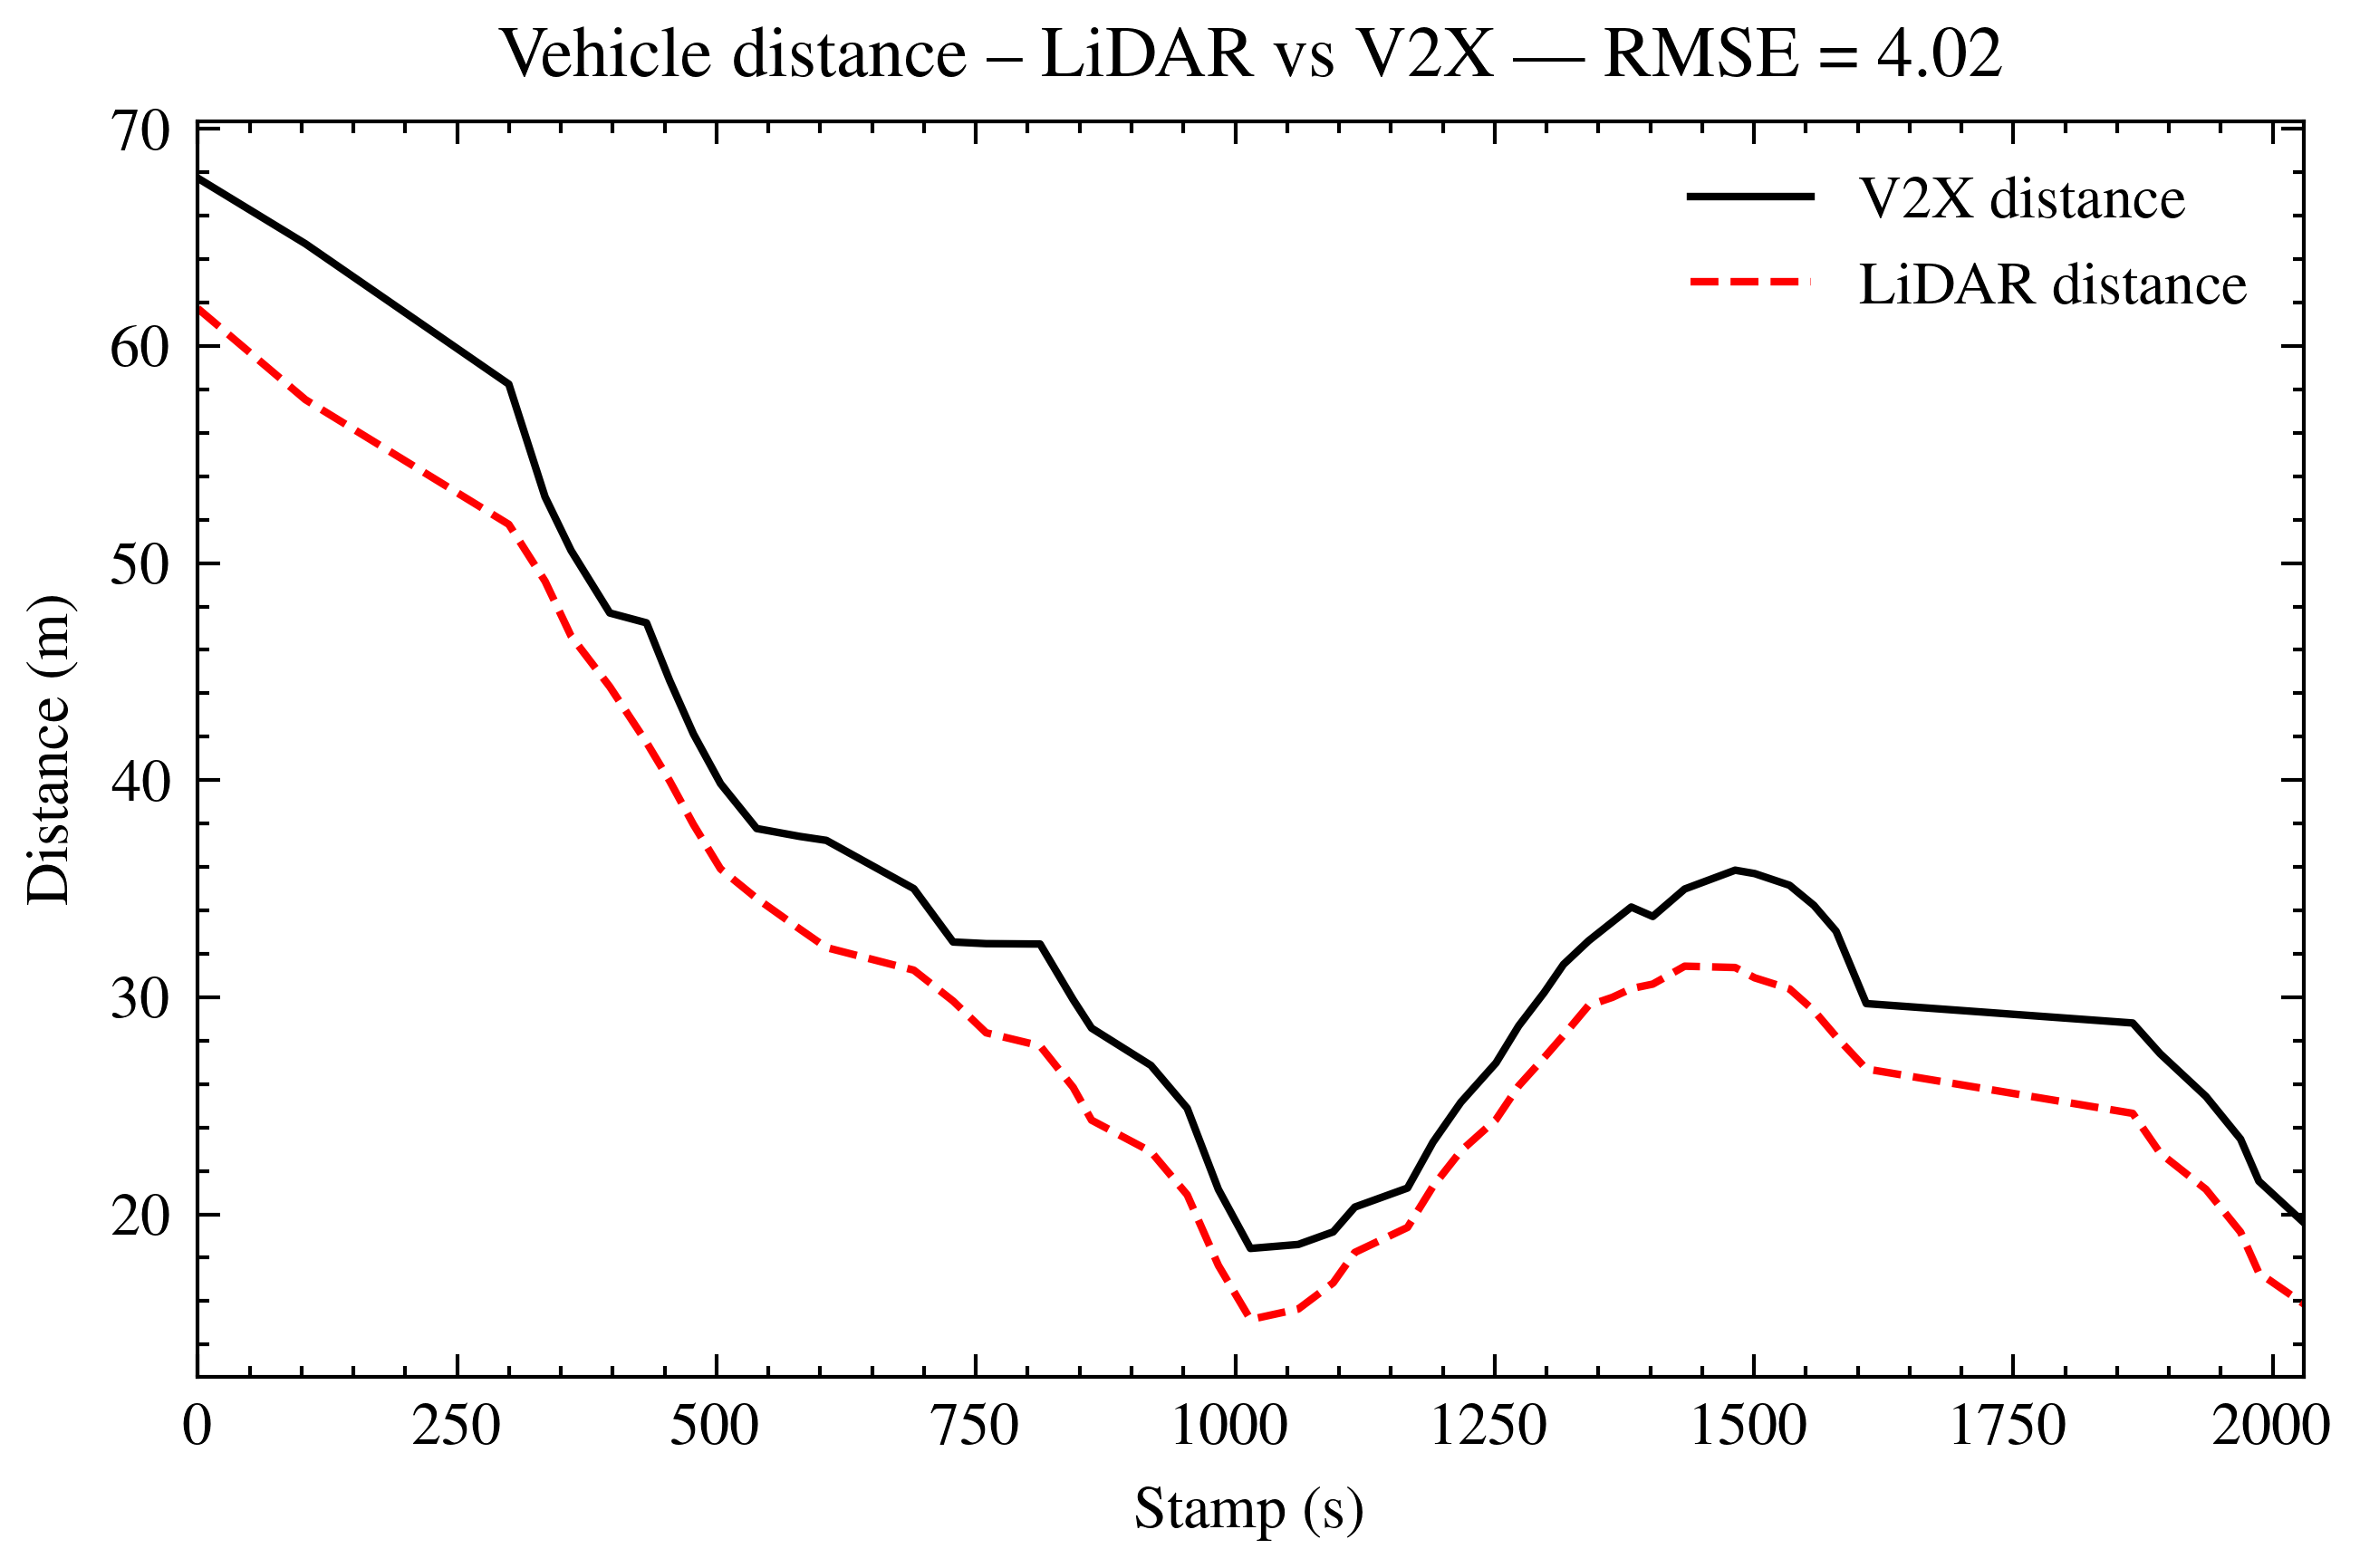

In [8]:
t = [stamp_daniel_i - stamp_daniel[0] for stamp_daniel_i in stamp_daniel]

plt.figure(figsize=(5, 3))

plt.plot(t, distance_v2x_daniel, label='V2X distance')
plt.plot(t, distance_lidar_daniel, label='LiDAR distance')
plt.xlabel('Stamp (s)')
plt.ylabel('Distance (m)')
plt.xlim(t[0],t[len(t)-1])
plt.title(f'Vehicle distance -- LiDAR vs V2X | RMSE = {rmse_daniel:.2f}')
plt.legend()
plt.savefig('Rua Daniel Hogan dataset RMSE.png', dpi=300) # Saves at 300 dpi
plt.savefig('Rua_Daniel_Hogan_dataset_RMSE.pdf', format='pdf')
plt.show()

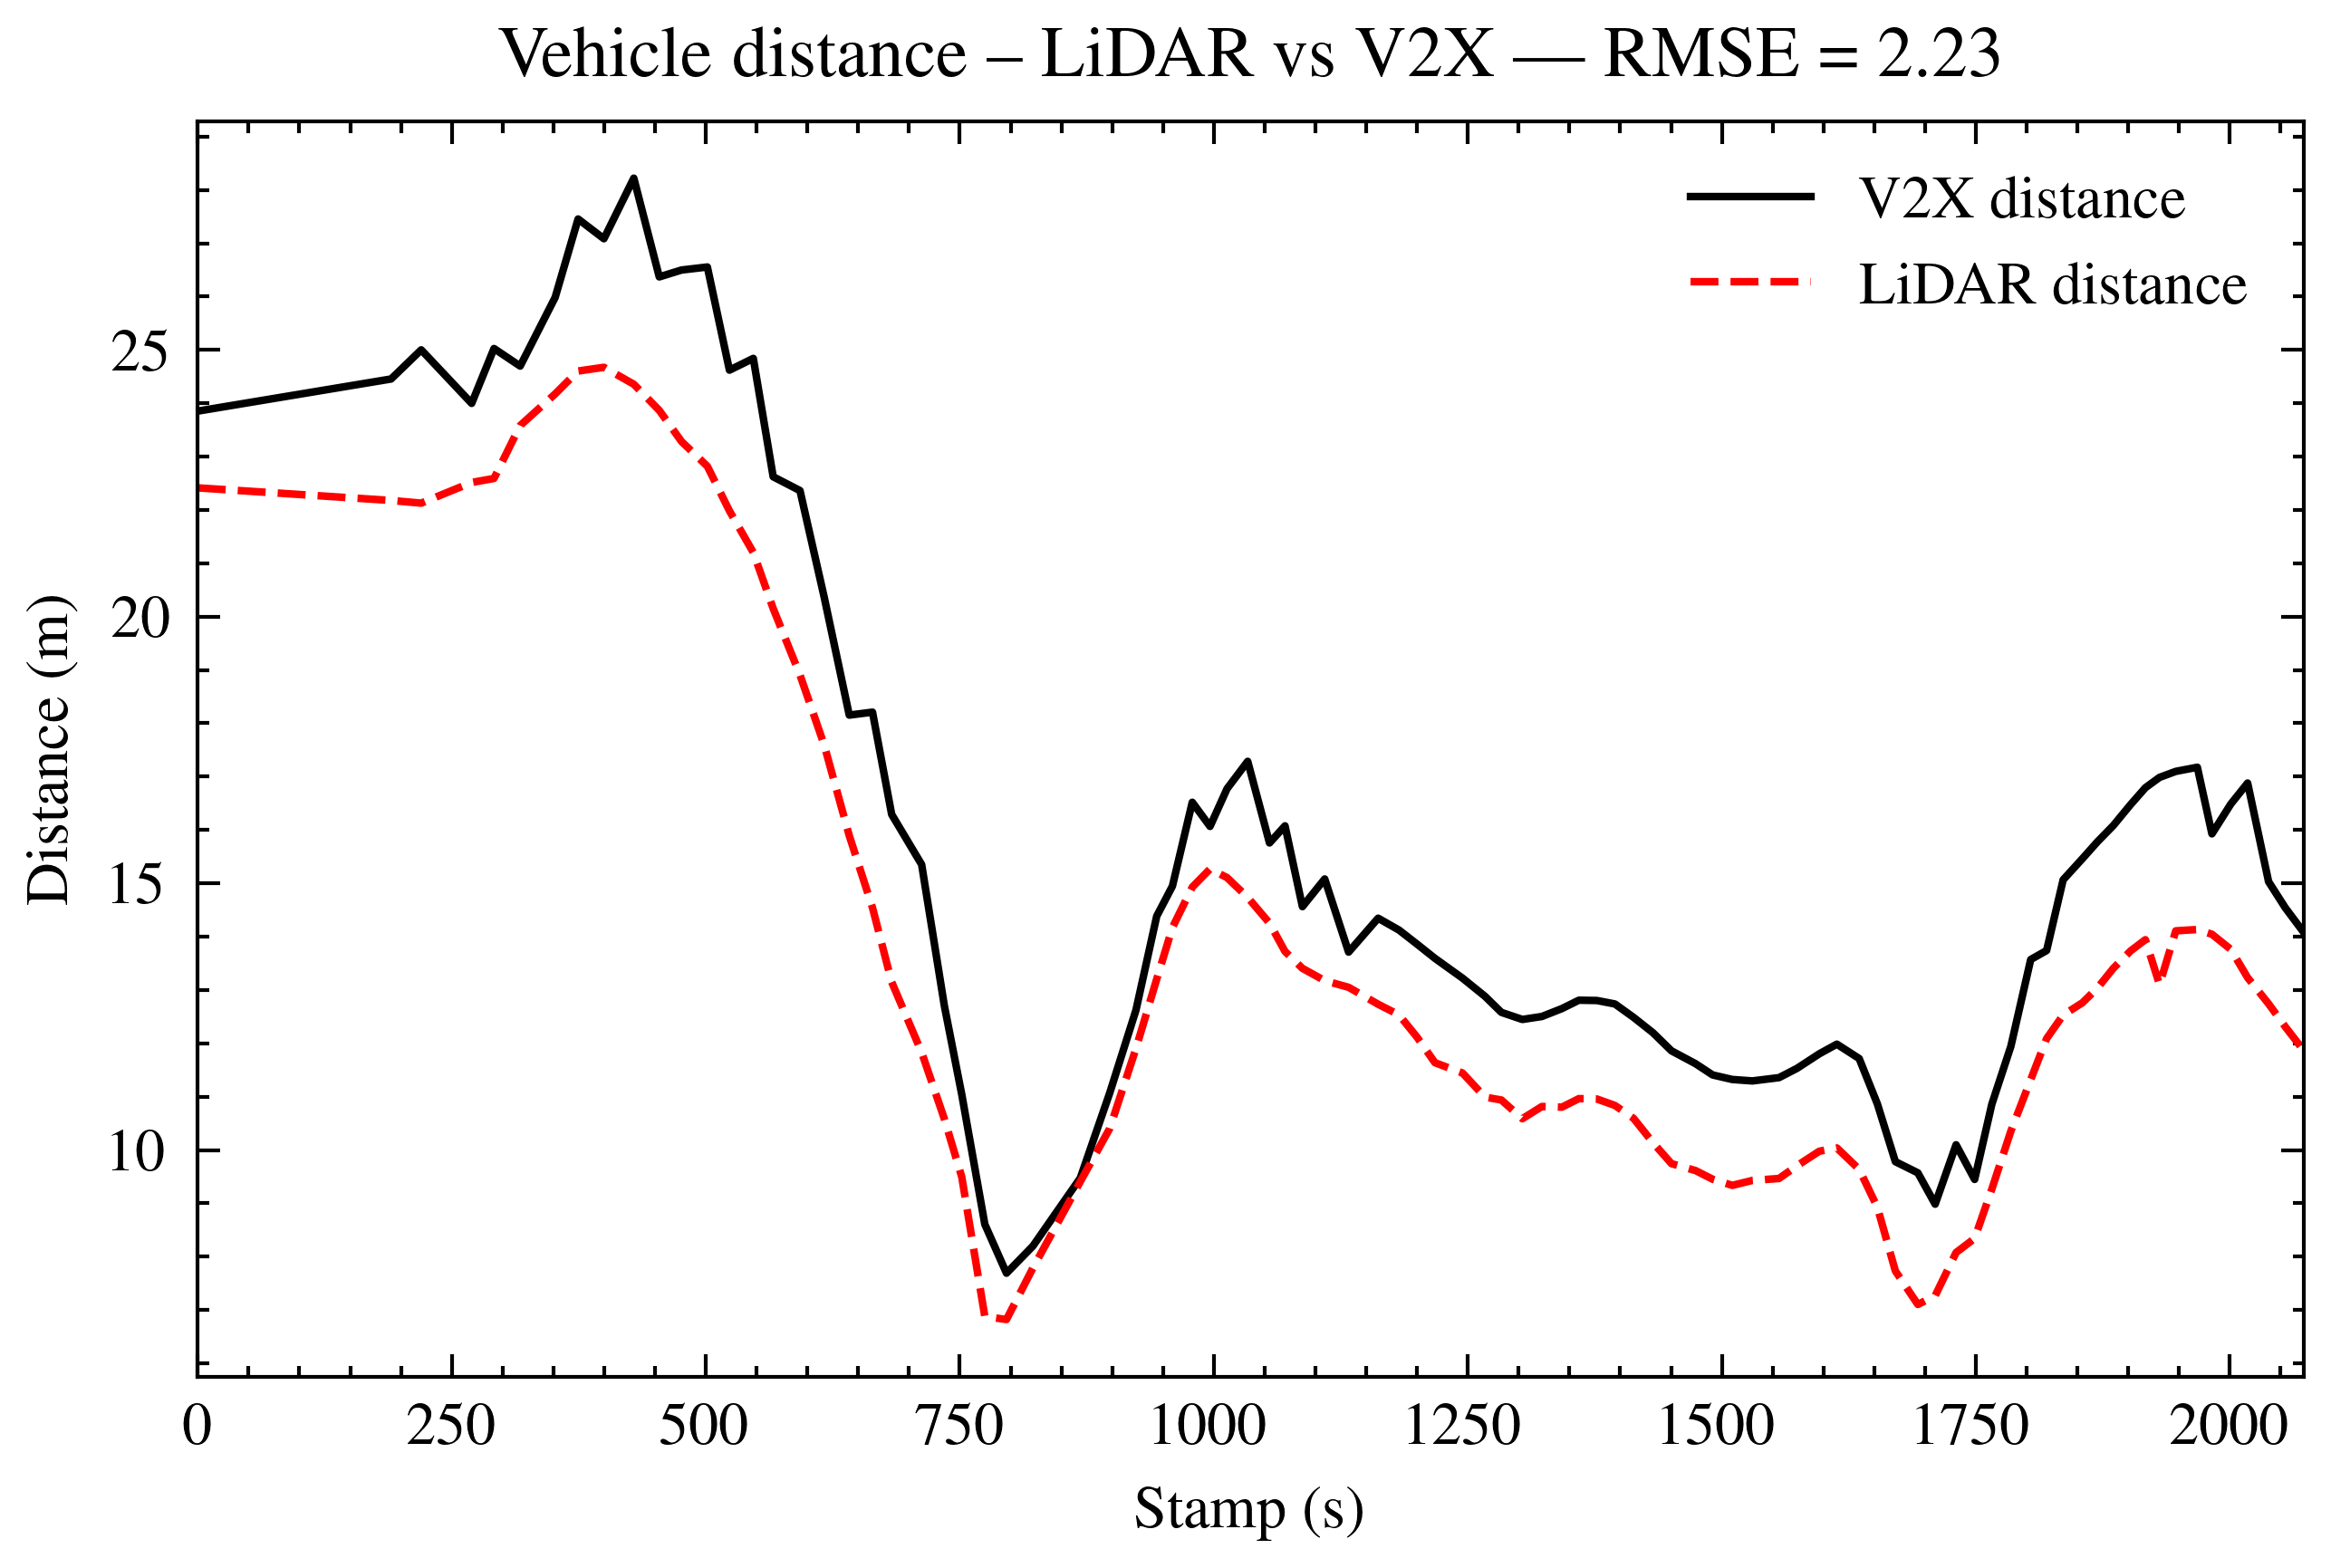

In [9]:
t = [stamp_walter_i - stamp_walter[0] for stamp_walter_i in stamp_walter]

plt.figure(figsize=(5, 3))

plt.plot(t, distance_v2x_walter, label='V2X distance')
plt.plot(t, distance_lidar_walter, label='LiDAR distance')
plt.xlabel('Stamp (s)')
plt.ylabel('Distance (m)')
plt.xlim(t[0],t[len(t)-1])
plt.title(f'Vehicle distance -- LiDAR vs V2X | RMSE = {rmse_walter:.2f}')
plt.legend()
plt.savefig('Rua Walter August Hadler dataset RMSE.png', dpi=300) # Saves at 300 dpi
plt.savefig('Rua_Walter_August_Hadler_dataset_RMSE.pdf', format='pdf')
plt.show()

In [10]:
stamp_daniel_np = np.array(stamp_daniel)
distance_v2x_daniel_np = np.array(distance_v2x_daniel)
distance_lidar_daniel_np = np.array(distance_lidar_daniel) + 2.5
stamp_walter_np = np.array(stamp_walter) 
distance_v2x_walter_np = np.array(distance_v2x_walter)
distance_lidar_walter_np = np.array(distance_lidar_walter) + 2.5

distance_daniel_np = distance_lidar_daniel_np - distance_v2x_daniel_np
distance_walter_np = distance_lidar_walter_np - distance_v2x_walter_np

distance_daniel_var = np.var(distance_daniel_np)
distance_daniel_std = np.std(distance_daniel_np)
distance_walter_var = np.var(distance_walter_np)
distance_walter_std = np.std(distance_walter_np)

rmse_daniel = np.sqrt(np.mean((distance_lidar_daniel_np - distance_v2x_daniel_np)**2))
rmse_walter = np.sqrt(np.mean((distance_lidar_walter_np - distance_v2x_walter_np)**2))


print("rmse_daniel : "+str(rmse_daniel))
print("distance_daniel_var : "+str(distance_daniel_var))
print("distance_daniel_std : "+str(distance_daniel_std))

print('--')

print("rmse_walter : "+str(rmse_walter))
print("distance_walter_var : "+str(distance_walter_var))
print("distance_walter_std : "+str(distance_walter_std))

rmse_daniel : 1.7492435148149041
distance_daniel_var : 1.162957744109015
distance_daniel_std : 1.0784051854980181
--
rmse_walter : 0.8878425793790657
distance_walter_var : 0.6188763266344142
distance_walter_std : 0.7866869305094716


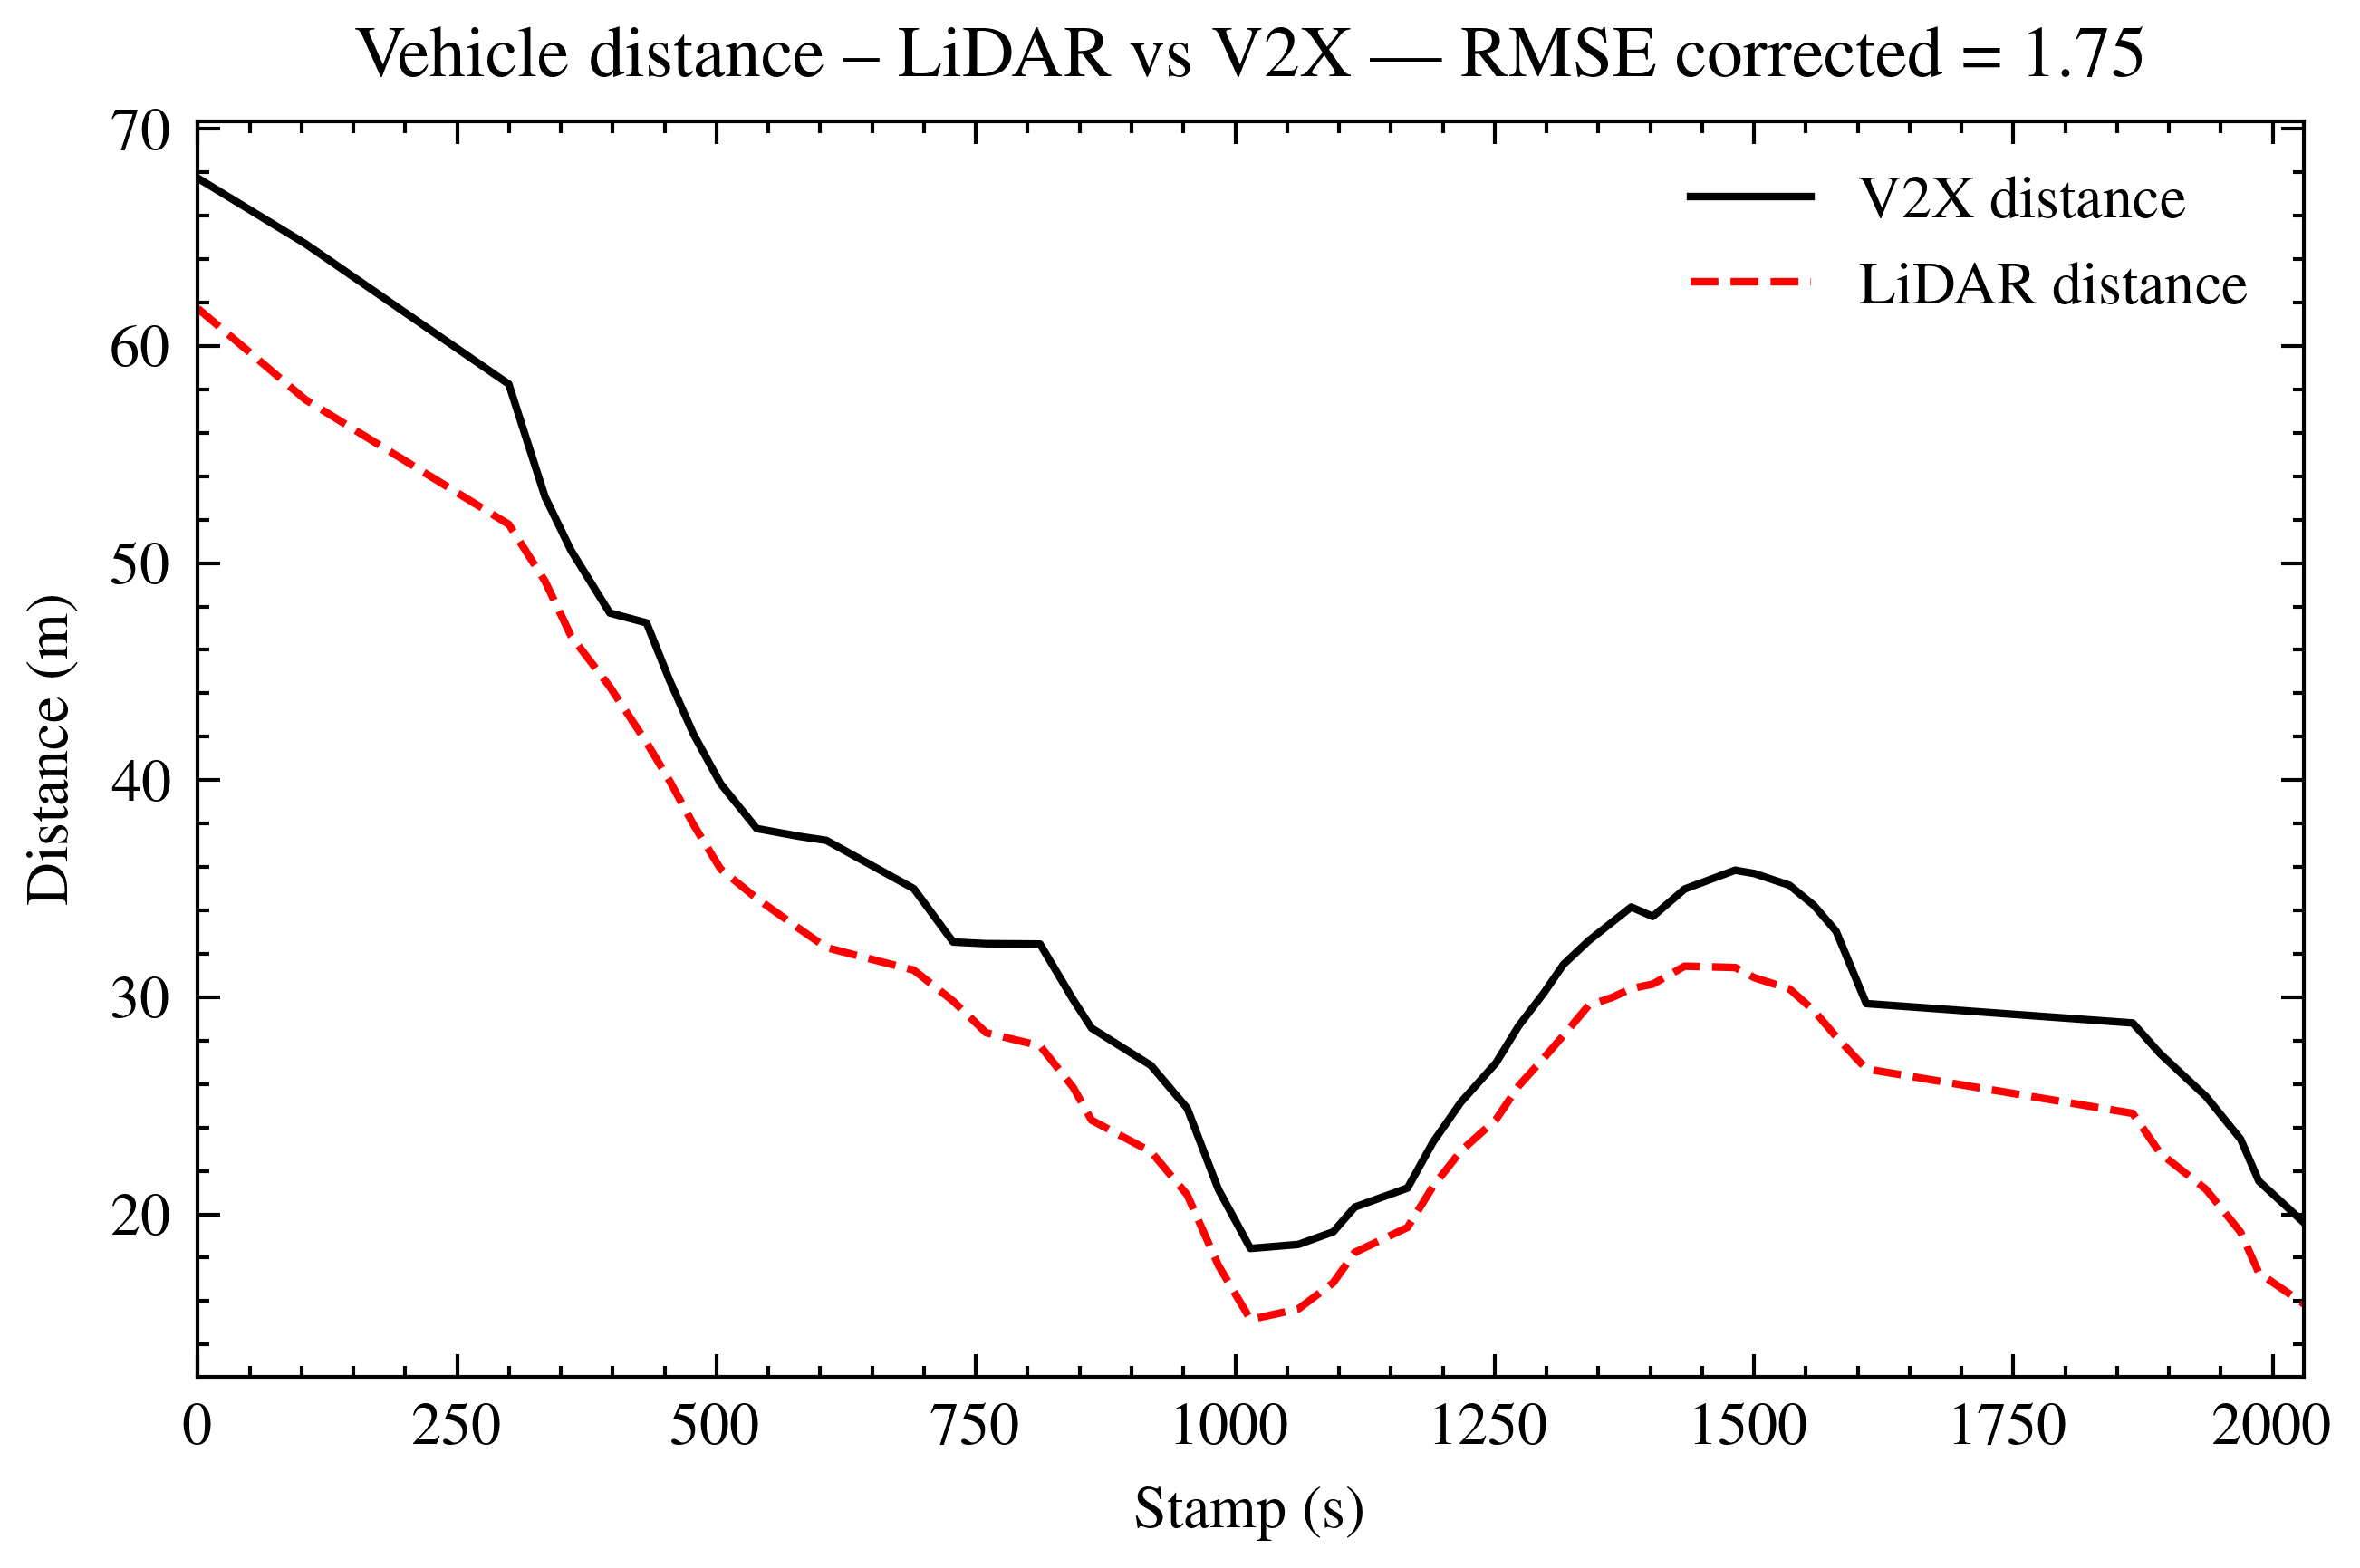

In [11]:
t = [stamp_daniel_i - stamp_daniel[0] for stamp_daniel_i in stamp_daniel]

plt.figure(figsize=(5, 3))

plt.plot(t, distance_v2x_daniel, label='V2X distance')
plt.plot(t, distance_lidar_daniel, label='LiDAR distance')
plt.xlabel('Stamp (s)')
plt.ylabel('Distance (m)')
plt.xlim(t[0],t[len(t)-1])
plt.title(f'Vehicle distance -- LiDAR vs V2X | RMSE corrected = {rmse_daniel:.2f}')
plt.legend()
plt.savefig('Rua Daniel Hogan dataset RMSE corrected.png', dpi=300) # Saves at 300 dpi
plt.savefig('Rua_Daniel_Hogan_dataset_RMSE_corrected.pdf', format='pdf')
plt.show()

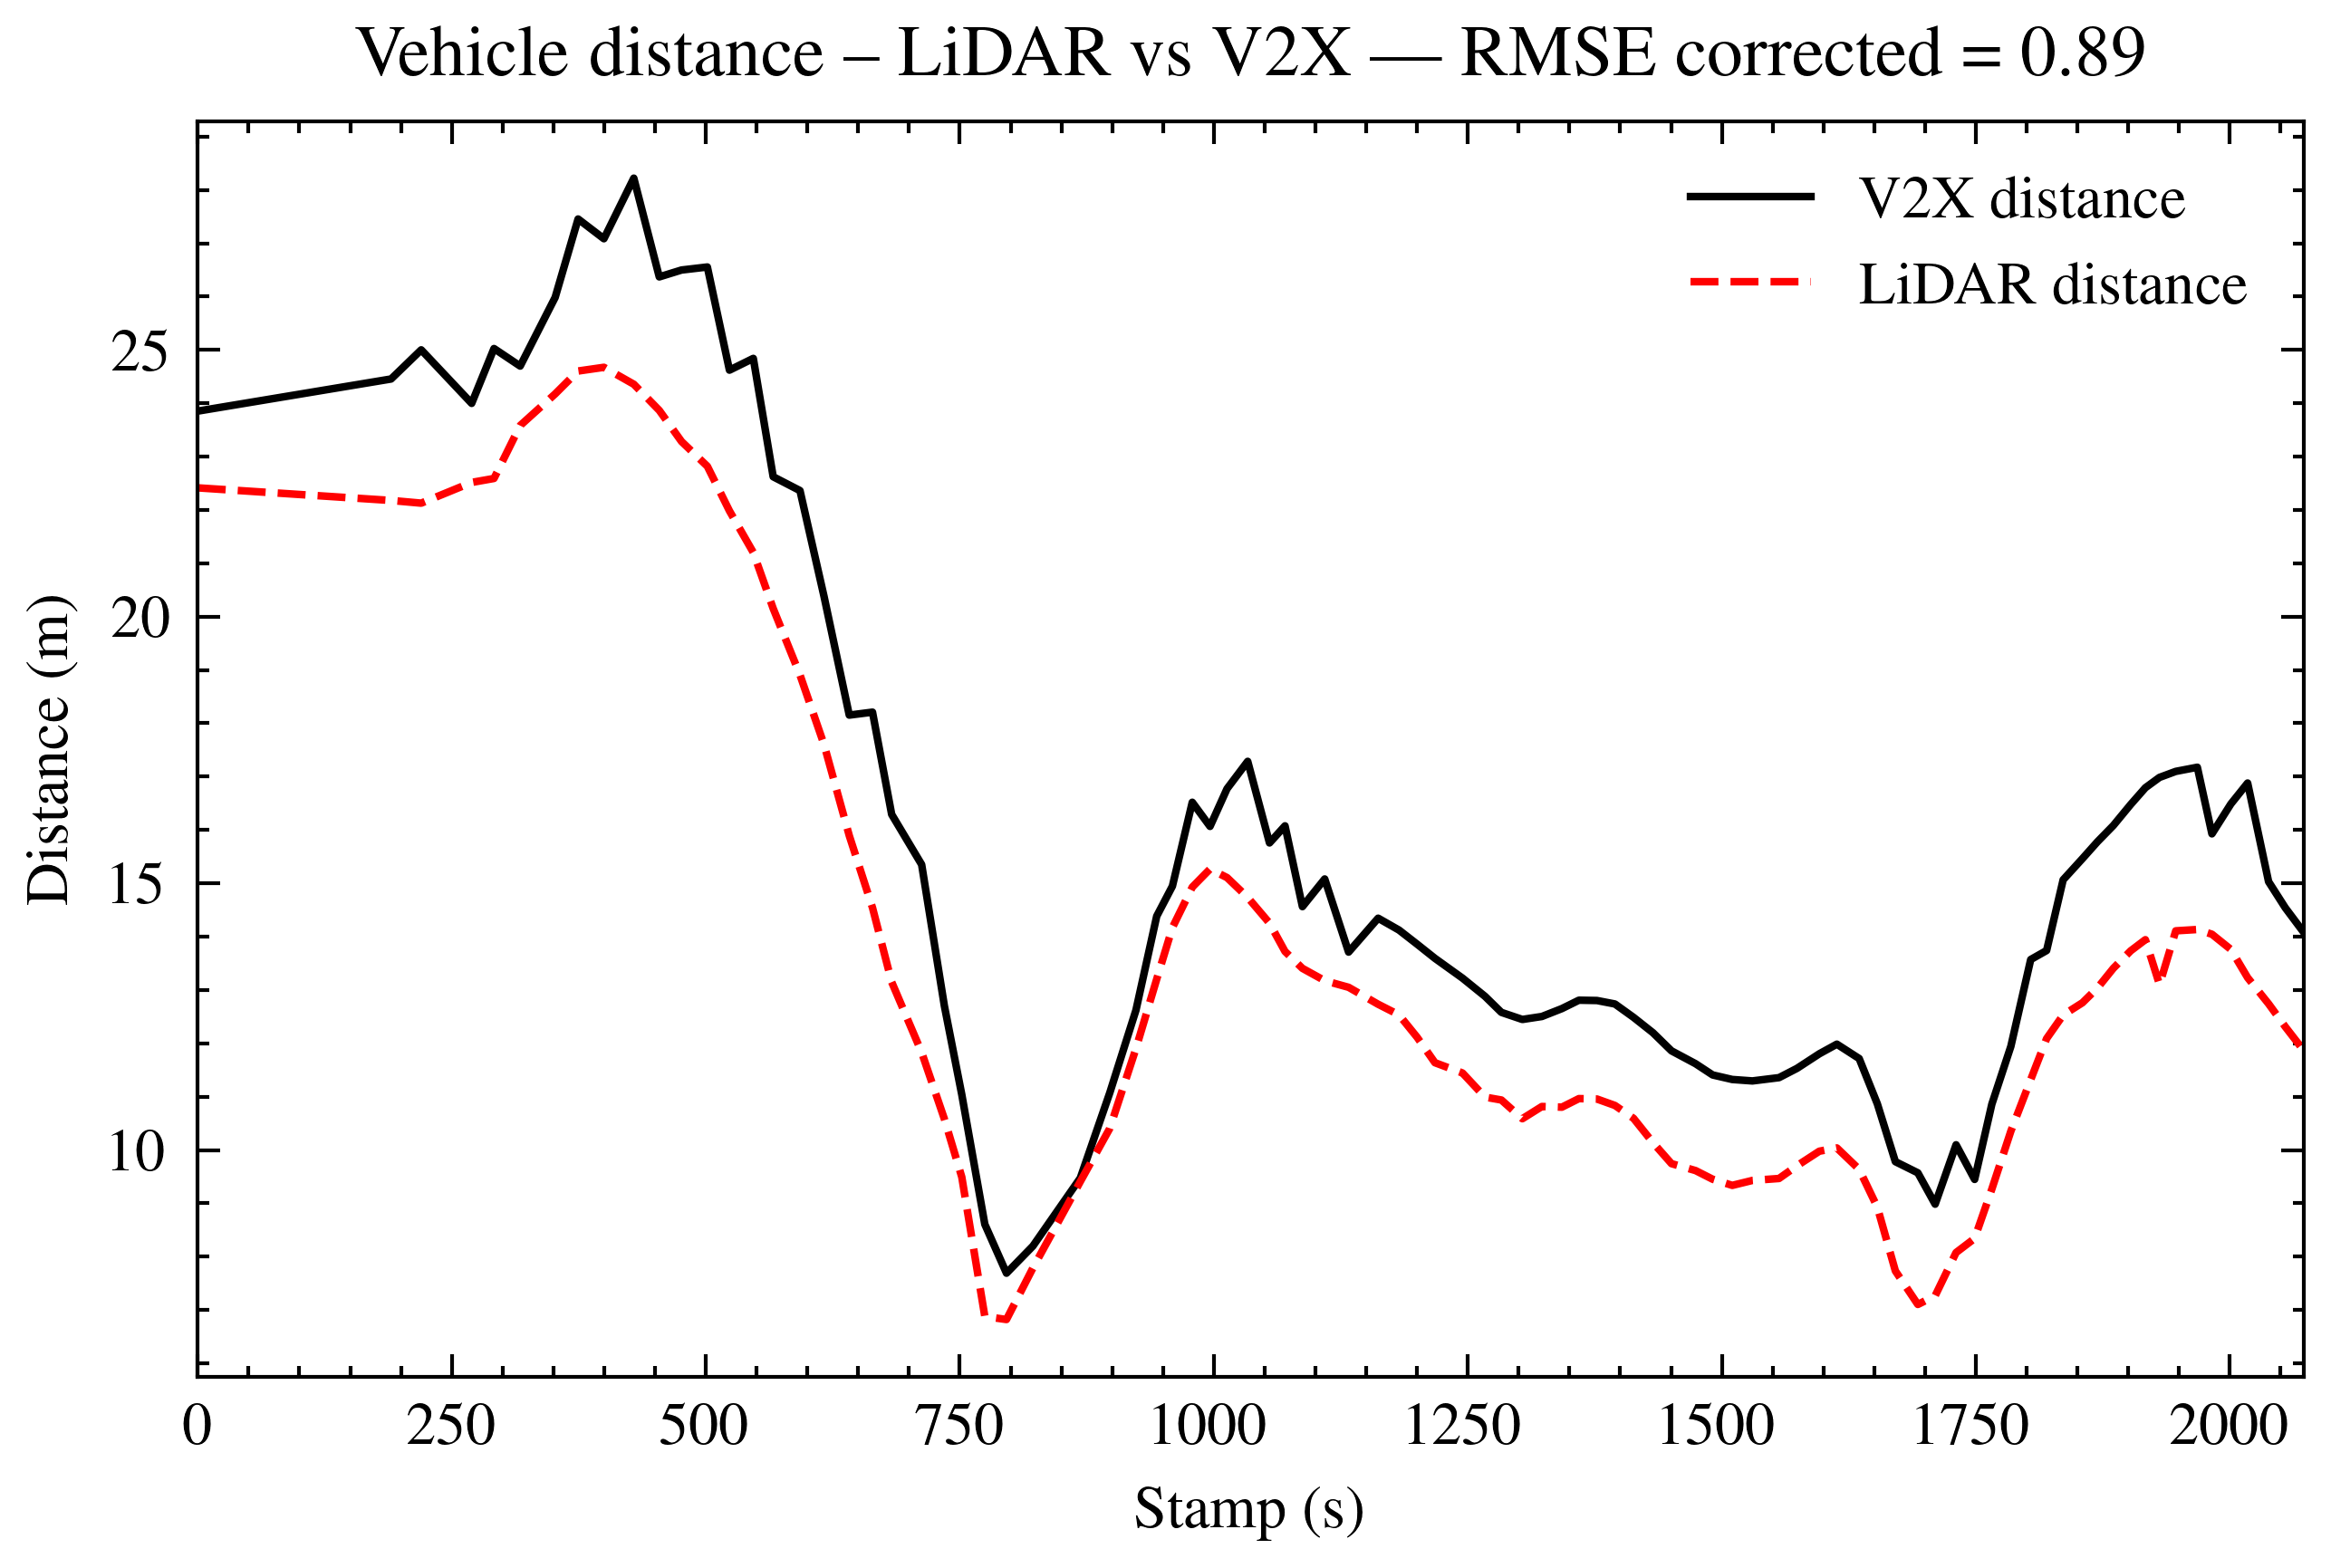

In [12]:
t = [stamp_walter_i - stamp_walter[0] for stamp_walter_i in stamp_walter]

plt.figure(figsize=(5, 3))

plt.plot(t, distance_v2x_walter, label='V2X distance')
plt.plot(t, distance_lidar_walter, label='LiDAR distance')
plt.xlabel('Stamp (s)')
plt.ylabel('Distance (m)')
plt.xlim(t[0],t[len(t)-1])
plt.title(f'Vehicle distance -- LiDAR vs V2X | RMSE corrected = {rmse_walter:.2f}')
plt.legend()
plt.savefig('Rua Walter August Hadler dataset RMSE corrected.png', dpi=300) # Saves at 300 dpi
plt.savefig('Rua_Walter_August_Hadler_dataset_RMSE_corrected.pdf', format='pdf')
plt.show()